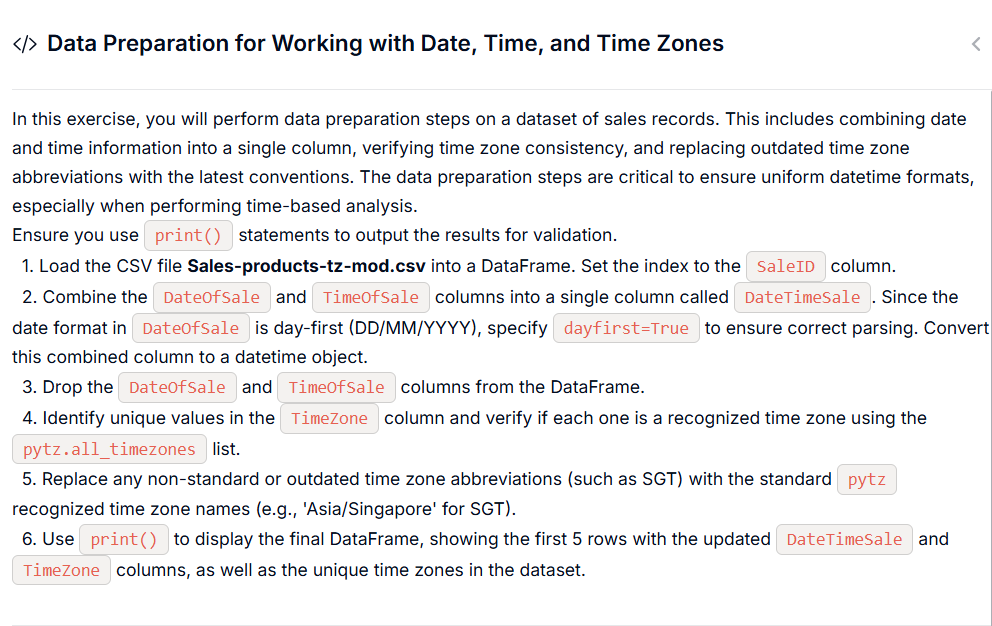

In [1]:
import pandas as pd
import pytz
from datetime import datetime

# Load data
data = pd.read_csv('Sales-products-tz-mod.csv', index_col='SaleID') 
sales_data = data.copy()

# Step 2: Combine date and time into DateTimeSale column with dayfirst=True
# sales_data['DateTimeSale'] = sales_data['DateOfSale']+" "+sales_data['TimeOfSale']
# Set dayfirst=True to intepret the date as day/month/year rather than the default month/day/year.
sales_data['DateTimeSale'] = pd.to_datetime(sales_data['DateOfSale'] + ' ' + sales_data['TimeOfSale'], dayfirst=True)

# sales_data

# Step 3: Drop unnecessary columns
sales_data = sales_data.drop(['DateOfSale', 'TimeOfSale'], axis=1)

# sales_data

# Step 4: Check and verify time zones
print("Unique Time Zones and Verification:")
for tz in sales_data['TimeZone'].unique():
    print(tz, ":", tz in pytz.all_timezones)

# Step 5: Replace non-standard time zone abbreviations
sales_data['TimeZone'] = sales_data['TimeZone'].replace({'SGT': 'Asia/Singapore'})

# sales_data

# Step 6: Display the final DataFrame
print("\nFinal DataFrame:")
print(sales_data.head())

# sales_data[sales_data['TimeZone'] == 'Asia/Singapore']

Unique Time Zones and Verification:
EST : True
CET : True
GMT : True
EET : True
SGT : False
Australia/West : True

Final DataFrame:
         RetailerCountry   RetailerType                    Product  \
SaleID                                                               
SaleID_1   United States  Outdoors Shop  TrailChef Deluxe Cook Set   
SaleID_2   United States  Outdoors Shop     TrailChef Double Flame   
SaleID_3   United States  Outdoors Shop                  Star Dome   
SaleID_4   United States  Outdoors Shop               Star Gazer 2   
SaleID_5           Italy  Outdoors Shop       Canyon Mule Carryall   

          Sales Revenue ($) TimeZone        DateTimeSale  
SaleID                                                    
SaleID_1              200.0      EST 2020-01-06 23:20:56  
SaleID_2                7.0      EST 2020-02-05 17:27:08  
SaleID_3               20.0      EST 2020-10-30 09:04:43  
SaleID_4               40.0      EST 2020-11-13 04:25:06  
SaleID_5              1